# Lesson 11 homework

# Zadanie 10 – Kompleksowe czyszczenie danych 

Wyczyść dataset Titanic stosując pełny pipeline: 
- Usuń kolumny z >60% NaN -Wypełnij Age medianą 
- Wypełnij Embarked dominantą 
- Usuń wiersze z pozostałymi NaN 

Wymagania: 
- Przed i po: wypisz kształt DataFrame 
- Sprawdź czy nie ma NaN 
- Porównaj rozkład Age przed i po


Kolumny po usunięciu tych z >60% NaN:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']

Usunięte kolumny: ['Cabin']

Mediana Age: 28.0
Dominanta Embarked: S

Kształt przed czyszczeniem: (891, 12)
Kształt po czyszczeniu: (891, 11)

Liczba NaN po czyszczeniu:
0


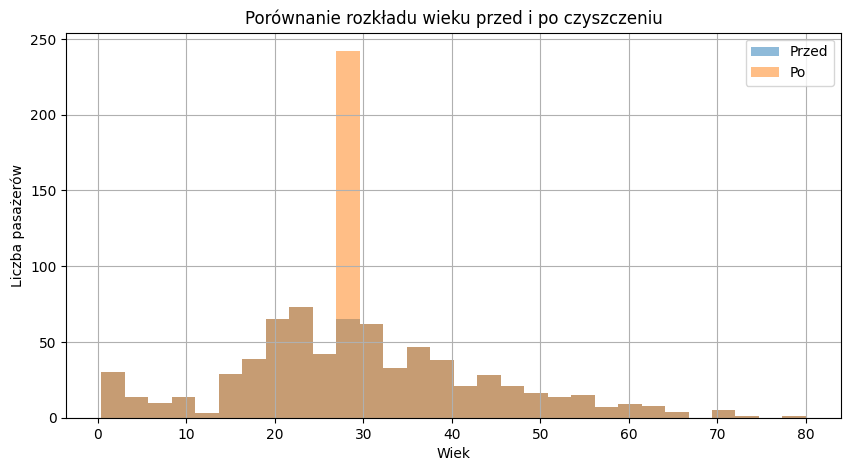

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Dataframe copy
df_clean = df.copy()

# Delete columns with <40% valid data
threshold = len(df_clean) * 0.4 
df_clean = df_clean.dropna(thresh=threshold, axis=1)
print("\nKolumny po usunięciu tych z >60% NaN:")
print(df_clean.columns.tolist())

# Removed columns
removed_cols = [col for col in df.columns if col not in df_clean.columns]
print("\nUsunięte kolumny:", removed_cols)

# Fill 'Age' column with age median
age_median = df_clean['Age'].median()
# df_clean['Age'].fillna(age_median, inplace=True)
df_clean.fillna({'Age': age_median}, inplace=True)
print(f"\nMediana Age: {age_median}")

# Fill 'Embarked' column with dominant value
embarked_mode = df_clean['Embarked'].mode()[0]
#df_clean['Embarked'].fillna(embarked_mode, inplace=True)
df_clean.fillna({'Embarked': embarked_mode}, inplace=True)
print(f"Dominanta Embarked: {embarked_mode}")

# Delete any row still containing NaN
df_clean = df_clean.dropna()
print("\nKształt przed czyszczeniem:", df.shape)
print("Kształt po czyszczeniu:", df_clean.shape)

# Check if any NaN still exists
print("\nLiczba NaN po czyszczeniu:")
print(df_clean.isnull().sum().sum())

# Age distribution comparison
plt.figure(figsize=(10,5))

df['Age'].dropna().hist(bins=30, alpha=0.5, label='Przed') # Before (without NaN)
df_clean['Age'].hist(bins=30, alpha=0.5, label='Po') # After

plt.xlabel("Wiek")
plt.ylabel("Liczba pasażerów")
plt.title("Porównanie rozkładu wieku przed i po czyszczeniu")
plt.legend()

plt.show()

# Zadanie 11 – Feature engineering

Stwórz nowe zmienne z Titanic:
- FamilySize = SibSp + Parch + 1
- IsAlone = 1 jeśli FamilySize == 1, inaczej 0
- AgeGroup = kategorie (0-12, 13-18, 19-35, 36-60, 60+)

Wymagania:
- Dodaj wszystkie 3 zmienne do DataFrame
- Wyświetl value_counts() dla każdej
- Oblicz wskaźnik przeżycia dla IsAlone vs nie alone

In [ ]:
# Data
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Fill empty rows in 'Age' with 'Age' median
#df['Age'].fillna(df['Age'].median(), inplace=True)
df.fillna({'Age': df['Age'].median()}, inplace=True)

# Add new column 'FamilySize'
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Add new column 'IsAlone'
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Add new column 'AgeGroup'
bins = [0, 12, 18, 35, 60, 100]
labels = ['Dziecko', 'Nastolatek', 'Dorosły', 'Starszy', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Value counts
print("FamilySize:")
print(df['FamilySize'].value_counts())

print("\nIsAlone:")
print(df['IsAlone'].value_counts())

print("\nAgeGroup:")
print(df['AgeGroup'].value_counts())

# Survival rate
survival = df.groupby('IsAlone')['Survived'].mean() * 100

print("\nWskaźnik przeżycia (%):")
print(survival)

FamilySize:
FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

IsAlone:
IsAlone
1    537
0    354
Name: count, dtype: int64

AgeGroup:
AgeGroup
Dorosły       535
Starszy       195
Nastolatek     70
Dziecko        69
Senior         22
Name: count, dtype: int64

Wskaźnik przeżycia (%):
IsAlone
0    50.564972
1    30.353818
Name: Survived, dtype: float64
